In [1]:
import numpy as np
import pandas as pd
from typing import Union
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from warnings import filterwarnings
from matplotlib.projections import PolarAxes
import mpl_toolkits.axisartist.grid_finder as gf
import mpl_toolkits.axisartist.floating_axes as fa
filterwarnings('ignore')


In [7]:
class TaylorDiagram(object):
    def __init__(self, STD, fig=None, rect=111, label='plot', 
                 color_grid:str='black', linestyle_grid:str='--', 
                 linewidth_grid:float=0.1, grid_alpha:float=0.5,
                 fontfamily:str='serif', fontsize:int=10, 
                 fontweight:str='normal',
                 size_xlabel: int = 12,
                 weight_xlabel: str = 'normal',
                 fontfamily_xlabel: str ='Georgia',
                 positive_only:bool=False,
                 title: str = None,
                 ylabel:str = 'Correlation Coeficient',
                 xlabel:str='Standard Value'): # Valor de correlação no ângulo de 0°
        
        self.STD = STD
        self.smin = 0.0
        self.smax = 1.5 * self.STD
        self.positive_only = positive_only
                
        tr = PolarAxes.PolarTransform()
        
        if positive_only:
            rlocs = np.array([0.0, 0.2, 0.4, 0.6, 0.8, 0.9, 0.95, 0.99, 1.0])
            extremes = (0, np.pi/2, self.smin, self.smax) 
        else:
            self.smin = -0.01
            positive_rlocs = np.array([0.0, 0.2, 0.4, 0.6, 0.8, 0.9, 0.95, 0.99])
            negative_rlocs = np.array([-0.2, -0.4, -0.6, -0.8, -0.9, -0.95, -0.99, -1.0])
            rlocs = np.concatenate([negative_rlocs, positive_rlocs])
            extremes = (0, np.pi, self.smin, self.smax)
        
        tlocs = np.arccos(rlocs)
        gl1 = gf.FixedLocator(tlocs)
        tf1 = gf.DictFormatter(dict(zip(tlocs, map(str, rlocs))))
        
        gh = fa.GridHelperCurveLinear(
            tr,
            extremes=extremes,
            grid_locator1=gl1,
            tick_formatter1=tf1
        )
        
        if fig is None:
            fig = plt.figure(figsize=(8, 6) if positive_only else (12, 8))  
        
        ax = fa.FloatingSubplot(fig, rect, grid_helper=gh)
        fig.add_subplot(ax)
        # Config AXES
        ax.axis['right'].set_axis_direction('top')
        ax.axis['left'].set_axis_direction('bottom')
        ax.axis['top'].set_axis_direction('bottom')
        if positive_only:
            ax.axis['top'].toggle(ticklabels=True, label=True)
            ax.axis['bottom'].toggle(ticklabels=False, label=False)
            ax.axis['right'].toggle(ticklabels=True, label=True)
            ax.axis['left'].toggle(ticklabels=True,label=True)
            ## Y axis
            ax.axis['top'].label.set_text(ylabel)
            ax.axis['top'].label.set_pad(20)
            ax.axis['top'].label.set_rotation(180)
            ax.axis['top'].label.set_fontsize(size_xlabel)  
            ax.axis['top'].label.set_fontname(fontfamily_xlabel)
            ax.axis['top'].label.set_fontweight(weight_xlabel)
            ## X axis
            ax.axis['left'].label.set_text(xlabel)
            ax.axis['left'].label.set_fontweight(weight_xlabel)
            ax.axis['left'].label.set_fontsize(size_xlabel)  
            ax.axis['left'].label.set_fontname(fontfamily_xlabel)
            ax.axis['left'].label.set_fontweight(weight_xlabel)
            ## Direction of the texts
            ax.axis['right'].major_ticklabels.set_axis_direction('left')
            ax.axis['top'].major_ticklabels.set_axis_direction('top')
            ax.set_position([0.1, 0.1, 0.7, 0.7])

        else:
            for kind in ['top','right']: 
                ax.axis[kind].toggle(ticklabels=True, label=True)
            ax.axis['top'].set_axis_direction('bottom')
            ax.axis['top'].major_ticklabels.set_axis_direction('top')
            ax.axis['right'].major_ticklabels.set_axis_direction('bottom')
            ax.axis['bottom'].toggle(ticklabels=True, label=True)
            ax.axis['top'].label.set_text(xlabel)
            ax.axis['top'].label.set_fontsize(size_xlabel)  
            ax.axis['top'].label.set_fontname(fontfamily_xlabel)
            ax.axis['top'].label.set_fontweight(weight_xlabel)
            ax.axis['top'].label.set_pad(-460)
            ax.axis['top'].label.set_rotation(180)




        
        # Aplicar configurações de fonte
        kinds = ['top', 'bottom', 'right', 'left']
        for kind in kinds:
            ax.axis[kind].major_ticklabels.set_fontname(fontfamily)
            ax.axis[kind].major_ticklabels.set_fontsize(fontsize)
            ax.axis[kind].major_ticklabels.set_fontweight(fontweight)

        ax.grid(color=color_grid, linestyle=linestyle_grid, 
                linewidth=linewidth_grid, alpha=grid_alpha)
        
        self._ax = ax
        self.ax = ax.get_aux_axes(tr)
        
        if title:
            if positive_only:
                self._ax.set_title(title, fontfamily=fontfamily, 
                                fontsize=fontsize+2, fontweight='bold',
                                pad=20)
            else:
                self._ax.set_title(ylabel, fontfamily=fontfamily, 
                                fontsize=fontsize, fontweight='bold',
                                pad=20)
        
        l, = self.ax.plot([0], self.STD, 'k*', ls='', ms=8, label=label)
        
        if positive_only:
            t = np.linspace(0, np.pi/2, 200)
        else:
            t = np.linspace(0, np.pi, 200)
            
        r = np.zeros_like(t) + self.STD
        self.ax.plot(t, r, 'k--', label='_')

        self.samplePoints = [l]

    def add_sample(self, STD, r, *args, **kwargs):
        # Garantir que correlações negativas não sejam plotadas se positive_only=True
        if self.positive_only and r < 0:
            print(f"Warning: The correlation and the r is negative (positive_only=True)")
            return None
        angle = np.arccos(r)
        l, = self.ax.plot(angle, STD, *args, **kwargs)
        self.samplePoints.append(l)
        return l

    def add_contours(self, levels=5, **kwargs):
        if self.positive_only:
            ts = np.linspace(0, np.pi/2, 100)  # 0 a 90°
        else:
            ts = np.linspace(0, np.pi, 100)    # 0 a 180°
            
        rs = np.linspace(self.smin, self.smax, 100)
        RS, TS = np.meshgrid(rs, ts)
        RMSE = np.sqrt(
            np.power(self.STD, 2) + np.power(RS, 2) -
            (2.0 * self.STD * RS * np.cos(TS))
        )
        contours = self.ax.contour(TS, RS, RMSE, levels, **kwargs)
        
        if 'label' in kwargs:    
            proxy = Line2D([0], [0], 
                        linestyle=kwargs.get('linestyle', '--'),
                        color=kwargs.get('colors', kwargs.get('color', 'darkred')), 
                        linewidth=kwargs.get('linewidths', kwargs.get('linewidth', 0.7)),
                        label=kwargs['label'])
            self.samplePoints.append(proxy)
            return contours
                


def params_RMSE(diagram, colors='darkred', linewidths=0.7, label='RMSE', 
                linestyles='--', fontsize=10, inline=True):
    contours = diagram.add_contours(
        colors=colors, 
        linewidths=linewidths, 
        label=label,
        linestyles=linestyles
    )
    if inline:
        plt.clabel(contours, fontsize=fontsize)
    return contours

def PlotTaylorDiagram(obsSTD: Union[list[float], np.ndarray, pd.Series],
         std_val_model: Union[list[float], np.ndarray, pd.Series], 
         r_values: Union[list[float], np.ndarray, pd.Series], 
         name_models: Union[list[str], np.ndarray, pd.Series],
         grid_params: dict = None, 
         font_params: dict = None,
         savefig: bool = False,
         name_fig: str='diagram.png',
         dpi: int=600,
         positive_only: bool = True,  # Forçando True para esta implementação
         title: str = None):
    
    '''
    Create a Taylor Diagram for model evaluation with interactive tooltips.
    
    Parameters:
    -----------
    obsSTD : float, list, np.ndarray, pd.Series
        Observed standard deviation (reference value)
        Standard deviation of the reference observational data
    
    std_val_model : list, np.ndarray, pd.Series
        Standard deviation values from models
        Model-predicted standard deviations to compare against observations
    
    r_values : list, np.ndarray, pd.Series
        Correlation coefficients between models and observations
        Pearson correlation coefficients (range: -1 to 1)
    
    name_models : list, np.ndarray, pd.Series
        Names of the models for legend identification
        Model identifiers for the legend
    
    grid_params : dict, optional
        Grid customization parameters
        Dictionary with keys:
          - color_grid: str (default: 'gray')
          - linestyle_grid: str (default: '-')
          - linewidth_grid: float (default: 0.6)
          - grid_alpha: float (default: 1)
    
    font_params : dict, optional
        Font customization parameters
        Dictionary with keys:
          - fontfamily: str (default: 'serif')
          - fontsize: int (default: 12)
          - fontweight: str (default: 'normal')
    
    savefig : bool, optional
        Whether to save the figure (default: False)
        Set to True to save the plot as image
    
    name_fig : str, optional
        Filename for saving the figure (default: 'diagram.png')
        Output filename when savefig=True
    
    dpi : int, optional
        DPI resolution for saved figure (default: 600)
        Image resolution quality
    
    positive_only : bool, optional
        Show only positive correlations (0 to 1) (default: False)
        If True, restricts display to positive correlation quadrant
    
    title : str, optional
        Plot title (default: None)
        Title text for the diagram
    
    '''
    s, r, l = std_val_model, r_values, name_models
    
    # Tamanho de figura diferente para positive_only
    if positive_only:
        fig = plt.figure(figsize=(8, 6))  # For positive correlations Figura menor para apenas 90°
    else:
        fig = plt.figure(figsize=(12, 8))  # For negative correlations 180°
    
    #  Default configuration for grid Params
    default_grid_params = {
        'color_grid': 'gray',
        'linestyle_grid': '-',
        'linewidth_grid': 0.6,
        'grid_alpha': 1
    }

    # Default configuration for font params
    default_font_params = {
        'fontfamily': 'Georgia',
        'fontsize': 12,
        'fontweight': 'normal',
        'size_xlabel': 12,
        'weight_xlabel':'normal',
        'fontfamily_xlabel':'Georgia'}
    
    # Mergin params from user
    if grid_params:
        default_grid_params.update(grid_params)
    if font_params:
        default_font_params.update(font_params)
    
    # Combine params from user
    all_params = {**default_grid_params, **default_font_params}
    all_params['positive_only'] = positive_only
    # Acessing class Taylor Diagram
    diagram = TaylorDiagram(obsSTD, fig=fig, rect=111, label='Observed', title=title,
                           **all_params)

    #Utils params From RMSE 
    params_RMSE(diagram=diagram,
    colors='darkred', 
    linewidths=0.8, 
    label='RMSE',
    linestyles='--',
    fontsize=10,
    inline=True)
    
    # Input the point into graphics 
    cs = plt.matplotlib.cm.Set1(np.linspace(0, 1, len(l)))
    srlc = zip(s, r, l, cs)
    for i in srlc:
        diagram.add_sample(i[0], i[1], label=i[2], c=i[3], marker='s')
    spl = [p.get_label() for p in diagram.samplePoints]
    
    # Legend Params
    fig.legend(
        diagram.samplePoints,
        spl,
        numpoints=1,
        prop=dict(size='medium', 
                 family=default_font_params['fontfamily'], 
                 weight=default_font_params['fontweight']),
        loc='center left',
        bbox_to_anchor=(0.9, 0.85) # multiple (0.82, 0.8)
    )
    
    plt.tight_layout(pad=0)
    if positive_only:
        plt.tight_layout(pad=0)
    else:
        plt.tight_layout(pad=-1)
    if savefig == True:
        plt.savefig(name_fig, dpi=dpi, bbox_inches='tight')
    return plt.show()

In [4]:
obsSTD = 0.35
s = [0.33, 0.34, 0.36, 0.38]
r = [0.7,-0.1, 0.81, 0.58]
l = ['A', 'B', 'C', 'D']


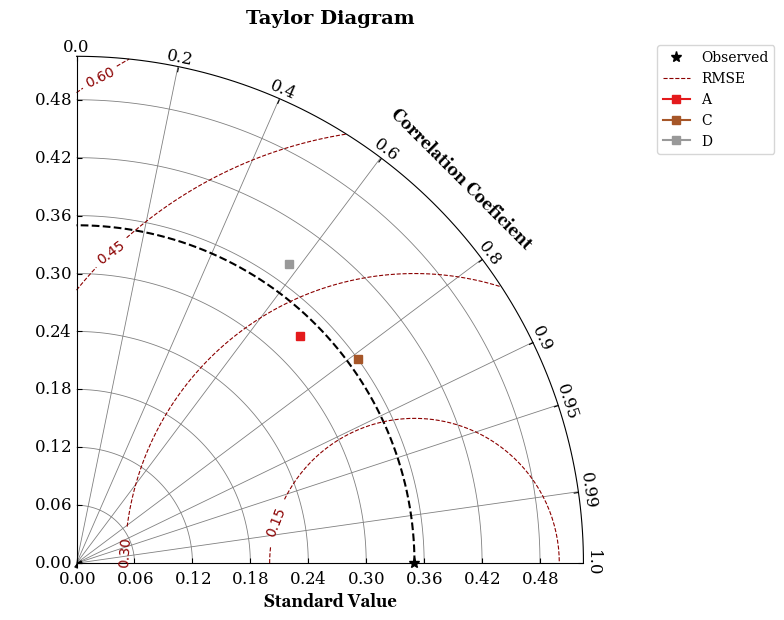

In [8]:
PlotTaylorDiagram(obsSTD=obsSTD,
                 std_val_model=s,
                 r_values=r,
                 name_models=l,
                 positive_only=True,
                 font_params={'fontsize':12,'fontfamily':'serif','weight_xlabel':'bold'},
                 title='Taylor Diagram',
                 savefig=False,name_fig='Negative.png')


In [18]:
import numpy as np
import pandas as pd
from typing import Union
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from warnings import filterwarnings
import mpl_toolkits.axisartist.angle_helper as angle_helper
from matplotlib.projections import PolarAxes
import mpl_toolkits.axisartist.grid_finder as grid_finder
import mpl_toolkits.axisartist.floating_axes as floating_axes
filterwarnings('ignore')

In [11]:
tr = PolarAxes.PolarTransform()
# if positive_only:
smin,smax = 0,1.5
rlocs = np.array([0.0, 0.2, 0.4, 0.6, 0.8, 0.9, 0.95, 0.99, 1.0])
extremes = (0, np.pi/2, smin, smax) 
# else:
#     self.smin = -0.01
#     positive_rlocs = np.array([0.0, 0.2, 0.4, 0.6, 0.8, 0.9, 0.95, 0.99])
#     negative_rlocs = np.array([-0.2, -0.4, -0.6, -0.8, -0.9, -0.95, -0.99, -1.0])
#     rlocs = np.concatenate([negative_rlocs, positive_rlocs])
#     extremes = (0, np.pi, self.smin, self.smax)

tlocs = np.arccos(rlocs) #ouput in radians
gl1 = grid_finder.FixedLocator(tlocs)
# tf1 = gf.DictFormatter(dict(zip(tlocs, map(str, rlocs))))
grid_finder

<module 'mpl_toolkits.axisartist.grid_finder' from 'c:\\Users\\Fernando\\.conda\\envs\\new_venv\\lib\\site-packages\\mpl_toolkits\\axisartist\\grid_finder.py'>

In [124]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.transforms import Affine2D
from mpl_toolkits.axisartist import floating_axes
from mpl_toolkits.axisartist import angle_helper
from mpl_toolkits.axisartist.grid_finder import MaxNLocator
from mpl_toolkits.axisartist.floating_axes import GridHelperCurveLinear
from mpl_toolkits.axisartist.floating_axes import FloatingAxes
from matplotlib.projections import PolarAxes
from mpl_toolkits.axisartist.grid_finder import FixedLocator, DictFormatter
from matplotlib.ticker import MultipleLocator, FormatStrFormatter
from mpl_toolkits.axisartist.grid_finder import FixedLocator, DictFormatter


In [191]:
from mpl_toolkits.axisartist.floating_axes import GridHelperCurveLinear


In [196]:
def setup_axes_taylor_zoom(fig, rect, theta_range=(0,1), r_range=(0,14000), angular=90):
    """
    Setup tipo diagrama de Taylor com zoom usando Affine2D,
    mantendo a origem radial visível.
    
    Parameters
    ----------
    theta_range : tuple
        Intervalo angular normalizado (0 a 1)
    r_range : tuple
        Intervalo radial (cz) desejado
    angular : float
        Arco angular do gráfico em graus (90, 120, etc.)
    """
    ra0, ra1 = theta_range
    cz0, cz1 = r_range

    # escala angular: normalizado [0,1] -> [-angular, 0]° -> radianos
    tr_theta = Affine2D().scale(-angular*np.pi/180., 1.).translate(np.pi/2, 0)
    
    # escala radial + translação para manter origem
    scale_r = 1.0 / (cz1 - cz0)  # normaliza para altura 1
    tr_radial = Affine2D().scale(1, scale_r).translate(0, -cz0*scale_r)
    
    # composição total: angular + radial + polares
    tr = tr_theta + tr_radial + PolarAxes.PolarTransform(apply_theta_transforms=False)
    
    # ticks angular
    tick_values = np.linspace(ra0, ra1, len(theta_range))
    grid_locator1 = FixedLocator(tick_values)
    tick_formatter1 = DictFormatter({v: f"{v:.2f}" for v in tick_values})
    
    # grid radial
    locs = MaxNLocator(4).tick_values(cz0, cz1)  # gera 4 ticks
    tick_values_r = locs[:-1]  # remove o último
    grid_locator2 = FixedLocator(tick_values_r)

    # Grid helper
    grid_helper = GridHelperCurveLinear(
        tr,extremes=(ra0, ra1, cz0, cz1),
        grid_locator1=grid_locator1,
        grid_locator2=grid_locator2,
        tick_formatter1=tick_formatter1,
        tick_formatter2=None)
    
    # eixo principal
    ax1 = fig.add_subplot(rect, axes_class=FloatingAxes,
                           grid_helper=grid_helper)
    
    # ajustes de eixos
    ax1.axis["left"].set_axis_direction("top")
    ax1.axis["right"].set_axis_direction("bottom")
    ax1.axis["bottom"].set_visible(False)
    ax1.axis["top"].toggle(ticklabels=True, label=True)
    ax1.axis["top"].major_ticklabels.set_axis_direction("top")
    ax1.axis['right'].toggle(ticklabels=True,label=True)
    ax1.axis["top"].label.set_axis_direction("top")
    ax1.axis['left'].major_ticklabels.set_axis_direction('left')
    ax1.axis["left"].label.set_text(r"cz [km$^{-1}$]")
    ax1.axis['right'].major_ticklabels.set_axis_direction('bottom')
    ax1.axis["top"].label.set_text("θ (normalizado)")
    ax1.grid()
    
    # parasite axes
    aux_ax = ax1.get_aux_axes(tr)
    aux_ax.patch = ax1.patch
    ax1.patch.zorder = 0.9
    
    # Normaliza theta automaticamente no plot do aux_ax
    _original_plot = aux_ax.plot
    def _plot_normalized_theta(x, y, *args, **kwargs):
        x_norm = (np.array(x) - ra0) / (ra1 - ra0)
        return _original_plot(x_norm, y, *args, **kwargs)
    aux_ax.plot = _plot_normalized_theta  # sobrescreve plot
    
    return ax1, aux_ax


In [102]:
r = [0,0.91,0.92,0.93]
std = [0.92,0.7,0.22,0.7]

In [ ]:
# dados de exemplo
theta = np.linspace(0.4,0.6,50)
r = 5000 + 200*np.sin(20*np.pi*theta)


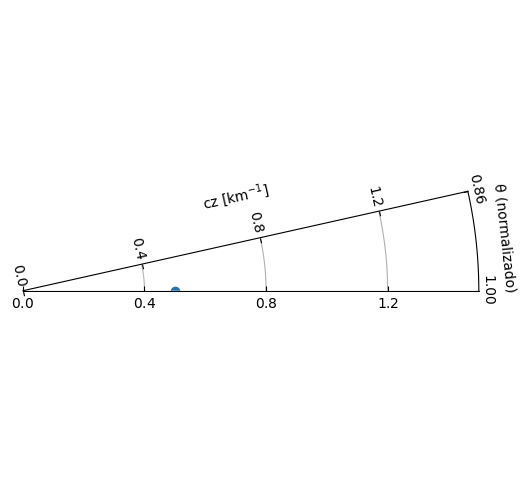

In [197]:
r = [0.86, 0.91, 0.92, 0.93, 1.0]
std = [0.92, 0.7, 0.22, 0.7, 0.5]

fig = plt.figure(figsize=(6,6))
ax1, aux_ax = setup_axes_taylor_zoom(fig, 111, theta_range=(0.86,1),
                                     r_range=(0,1.5), angular=90)

aux_ax.plot(r, std, "o")  # r é normalizado automaticamente
plt.show()
